# 02 — Data Quality and Exploratory Data Analysis

## Brazilian E-Commerce Analytics Portfolio

This notebook performs data-quality validation and exploratory data analysis for the Olist e-commerce datasets.

### Objectives

1. Load the raw relational datasets.
2. Validate missing values, duplicates, identifiers, relationships, dates, numeric fields, and categorical values.
3. Build cleaned analytical tables for later notebooks.
4. Create exploratory summaries and figures.
5. Export reproducible data-quality and EDA artifacts.

### Main questions answered by this notebook

- Which datasets contain missing values?
- Are there duplicate records or duplicate identifiers?
- Are relational keys consistent across tables?
- Are dates logically consistent?
- Are prices, freight values, payments, and review scores valid?
- What are the main order statuses, payment types, states, review scores, and product categories?
- Are the data ready for revenue, retention, and statistical analysis?

> This notebook focuses on data quality and exploratory analysis. Detailed revenue, retention, and statistical testing are handled in later notebooks.

## Methodology workflow

```text
Raw CSV files
      ↓
Load relational tables
      ↓
Validate missing values and duplicates
      ↓
Check key identifiers and parent-child relationships
      ↓
Validate dates, numeric fields, and categorical values
      ↓
Create order-level and customer-level analytical tables
      ↓
Generate exploratory summaries and figures
      ↓
Export processed datasets and reports
```

The corresponding workflow image can be stored as:

```text
workflows/02_data_quality_and_eda_workflow.png
```

## 1. Import libraries and configure the environment

In [6]:
from pathlib import Path
from typing import Dict, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version:  {np.__version__}")

Pandas version: 2.2.2
NumPy version:  2.0.2


## 2. Resolve project directories

The notebook can run from the repository root, from `notebooks/`, or from an application-specific folder such as `applications/olist_ecommerce/notebooks/`.

In [7]:
from pathlib import Path
import kagglehub

# -----------------------------------------------------
# Colab-compatible path configuration
# -----------------------------------------------------

# Current Colab working directory
PROJECT_ROOT = Path.cwd()

# Download or access the cached Olist dataset from KaggleHub
RAW_DATA_DIR = Path(
    kagglehub.dataset_download("olistbr/brazilian-ecommerce")
)

# Output directories for processed data and reports
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

# Create output folders if they do not exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root:       {PROJECT_ROOT}")
print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Processed data:     {PROCESSED_DATA_DIR}")
print(f"Figures directory:  {FIGURES_DIR}")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Project root:       /content
Raw data directory: /kaggle/input/brazilian-ecommerce
Processed data:     /content/data/processed
Figures directory:  /content/reports/figures


In [8]:
FILE_NAMES = {
    "customers": "olist_customers_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

## 3. Load raw datasets

In [9]:
FILE_NAMES = {
    "customers": "olist_customers_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

DATE_COLUMNS = {
    "orders": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
    "order_items": ["shipping_limit_date"],
    "reviews": ["review_creation_date", "review_answer_timestamp"],
}


def load_dataset(
    file_path: Path,
    date_columns: Iterable[str] | None = None,
) -> pd.DataFrame:
    """Load one CSV file and parse date columns when available."""
    dataframe = pd.read_csv(file_path, low_memory=False)

    if date_columns:
        for column in date_columns:
            if column in dataframe.columns:
                dataframe[column] = pd.to_datetime(dataframe[column], errors="coerce")

    return dataframe


missing_files = [
    file_name
    for file_name in FILE_NAMES.values()
    if not (RAW_DATA_DIR / file_name).exists()
]

if missing_files:
    missing_text = "\n".join(f"- {name}" for name in missing_files)
    raise FileNotFoundError(
        "The following required files are missing from data/raw/:\n"
        f"{missing_text}"
    )

datasets: Dict[str, pd.DataFrame] = {}

for dataset_name, file_name in FILE_NAMES.items():
    datasets[dataset_name] = load_dataset(
        file_path=RAW_DATA_DIR / file_name,
        date_columns=DATE_COLUMNS.get(dataset_name),
    )

for dataset_name, dataframe in datasets.items():
    print(
        f"{dataset_name:<22} "
        f"{dataframe.shape[0]:>8,} rows × {dataframe.shape[1]:>2} columns"
    )

customers                99,441 rows ×  5 columns
orders                   99,441 rows ×  8 columns
order_items             112,650 rows ×  7 columns
payments                103,886 rows ×  5 columns
reviews                  99,224 rows ×  7 columns
products                 32,951 rows ×  9 columns
sellers                   3,095 rows ×  4 columns
category_translation         71 rows ×  2 columns


## 4. Dataset inventory

This summary provides a high-level view of table size, missing values, duplicates, and memory usage.

In [10]:
inventory_records = []

for dataset_name, dataframe in datasets.items():
    file_path = RAW_DATA_DIR / FILE_NAMES[dataset_name]

    inventory_records.append(
        {
            "dataset": dataset_name,
            "source_file": file_path.name,
            "rows": len(dataframe),
            "columns": dataframe.shape[1],
            "missing_cells": int(dataframe.isna().sum().sum()),
            "missing_cell_percentage": round(
                100 * dataframe.isna().sum().sum() / max(dataframe.size, 1),
                4,
            ),
            "exact_duplicate_rows": int(dataframe.duplicated().sum()),
            "memory_mb": round(dataframe.memory_usage(deep=True).sum() / 1_048_576, 3),
            "source_file_mb": round(file_path.stat().st_size / 1_048_576, 3),
        }
    )

data_inventory = pd.DataFrame(inventory_records).sort_values("dataset").reset_index(drop=True)
data_inventory

,dataset,source_file,rows,columns,missing_cells,missing_cell_percentage,exact_duplicate_rows,memory_mb,source_file_mb
0,category_translation,product_category_name_translation.csv,71,2,0,0.0000,0,0.009,0.002
1,customers,olist_customers_dataset.csv,99441,5,0,0.0000,0,26.586,8.615
2,order_items,olist_order_items_dataset.csv,112650,7,0,0.0000,0,29.544,14.723
3,orders,olist_orders_dataset.csv,99441,8,4908,0.6169,0,24.655,16.837
4,payments,olist_order_payments_dataset.csv,103886,5,0,0.0000,0,16.229,5.510
5,products,olist_products_dataset.csv,32951,9,2448,0.8255,0,6.297,2.269
6,reviews,olist_order_reviews_dataset.csv,99224,7,145903,21.0063,0,27.769,13.782
7,sellers,olist_sellers_dataset.csv,3095,4,0,0.0000,0,0.588,0.167


### Figure — Missing cells by dataset

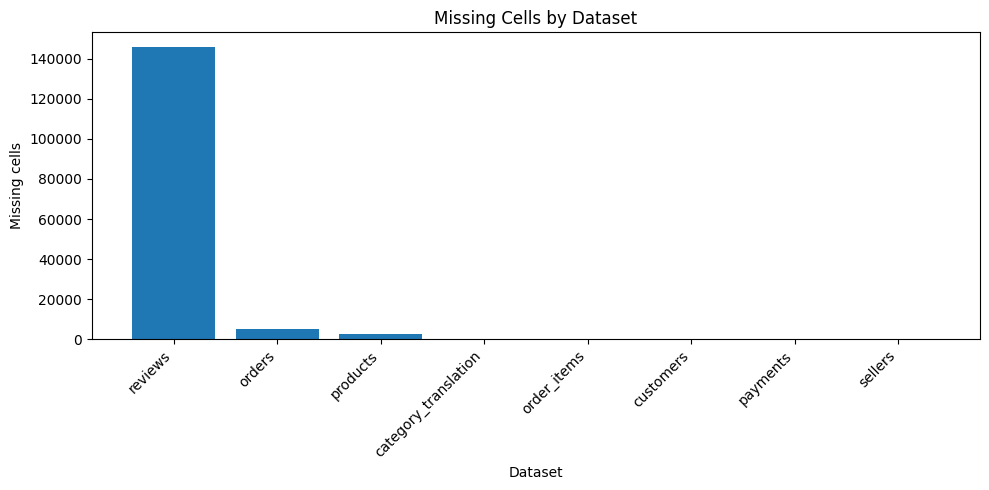

Saved figure: reports/figures/missing_cells_by_dataset.png


In [11]:
missing_by_dataset = data_inventory.sort_values("missing_cells", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(missing_by_dataset["dataset"], missing_by_dataset["missing_cells"])
plt.title("Missing Cells by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Missing cells")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

missing_cells_figure_path = FIGURES_DIR / "missing_cells_by_dataset.png"
plt.savefig(missing_cells_figure_path, dpi=150)
plt.show()

print(f"Saved figure: {missing_cells_figure_path.relative_to(PROJECT_ROOT)}")

## 5. Missing-value analysis by column

This table identifies which columns require special attention during cleaning or interpretation.

In [12]:
missing_column_records = []

for dataset_name, dataframe in datasets.items():
    for column in dataframe.columns:
        missing_count = int(dataframe[column].isna().sum())
        missing_column_records.append(
            {
                "dataset": dataset_name,
                "column": column,
                "dtype": str(dataframe[column].dtype),
                "missing_count": missing_count,
                "missing_percentage": round(100 * missing_count / max(len(dataframe), 1), 4),
                "unique_values": int(dataframe[column].nunique(dropna=True)),
            }
        )

missing_by_column = (
    pd.DataFrame(missing_column_records)
    .sort_values(["missing_percentage", "missing_count"], ascending=False)
    .reset_index(drop=True)
)

missing_by_column.head(30)

,dataset,column,dtype,missing_count,missing_percentage,unique_values
0,reviews,review_comment_title,object,87656,88.3415,4527
1,reviews,review_comment_message,object,58247,58.7025,36159
2,orders,order_delivered_customer_date,datetime64[ns],2965,2.9817,95664
3,products,product_category_name,object,610,1.8512,73
4,products,product_name_lenght,float64,610,1.8512,66
5,products,product_description_lenght,float64,610,1.8512,2960
6,products,product_photos_qty,float64,610,1.8512,19
7,orders,order_delivered_carrier_date,datetime64[ns],1783,1.7930,81018
8,orders,order_approved_at,datetime64[ns],160,0.1609,90733
9,products,product_weight_g,float64,2,0.0061,2204


## 6. Duplicate and key validation

The project checks exact duplicate rows and duplicates in important identifiers.

In [13]:
duplicate_summary = (
    pd.DataFrame(
        [
            {
                "dataset": dataset_name,
                "exact_duplicate_rows": int(dataframe.duplicated().sum()),
            }
            for dataset_name, dataframe in datasets.items()
        ]
    )
    .sort_values("exact_duplicate_rows", ascending=False)
    .reset_index(drop=True)
)

duplicate_summary

,dataset,exact_duplicate_rows
0,customers,0
1,orders,0
2,order_items,0
3,payments,0
4,reviews,0
5,products,0
6,sellers,0
7,category_translation,0


In [14]:
key_checks = pd.DataFrame(
    [
        {
            "dataset": "customers",
            "key": "customer_id",
            "duplicate_key_rows": int(datasets["customers"].duplicated(subset=["customer_id"], keep=False).sum()),
        },
        {
            "dataset": "orders",
            "key": "order_id",
            "duplicate_key_rows": int(datasets["orders"].duplicated(subset=["order_id"], keep=False).sum()),
        },
        {
            "dataset": "order_items",
            "key": "order_id + order_item_id",
            "duplicate_key_rows": int(
                datasets["order_items"].duplicated(subset=["order_id", "order_item_id"], keep=False).sum()
            ),
        },
        {
            "dataset": "payments",
            "key": "order_id + payment_sequential",
            "duplicate_key_rows": int(
                datasets["payments"].duplicated(subset=["order_id", "payment_sequential"], keep=False).sum()
            ),
        },
        {
            "dataset": "products",
            "key": "product_id",
            "duplicate_key_rows": int(datasets["products"].duplicated(subset=["product_id"], keep=False).sum()),
        },
        {
            "dataset": "sellers",
            "key": "seller_id",
            "duplicate_key_rows": int(datasets["sellers"].duplicated(subset=["seller_id"], keep=False).sum()),
        },
    ]
)

key_checks

,dataset,key,duplicate_key_rows
0,customers,customer_id,0
1,orders,order_id,0
2,order_items,order_id + order_item_id,0
3,payments,order_id + payment_sequential,0
4,products,product_id,0
5,sellers,seller_id,0


## 7. Parent-child relationship validation

This check identifies orphan keys, which are child records that reference missing parent records.

In [15]:
def count_orphan_keys(child: pd.DataFrame, child_key: str, parent: pd.DataFrame, parent_key: str) -> int:
    """Count distinct non-null child keys missing from the parent table."""
    child_values = set(child[child_key].dropna().unique())
    parent_values = set(parent[parent_key].dropna().unique())
    return len(child_values - parent_values)


relationship_checks = pd.DataFrame(
    [
        {
            "relationship": "orders.customer_id -> customers.customer_id",
            "orphan_keys": count_orphan_keys(datasets["orders"], "customer_id", datasets["customers"], "customer_id"),
        },
        {
            "relationship": "order_items.order_id -> orders.order_id",
            "orphan_keys": count_orphan_keys(datasets["order_items"], "order_id", datasets["orders"], "order_id"),
        },
        {
            "relationship": "payments.order_id -> orders.order_id",
            "orphan_keys": count_orphan_keys(datasets["payments"], "order_id", datasets["orders"], "order_id"),
        },
        {
            "relationship": "reviews.order_id -> orders.order_id",
            "orphan_keys": count_orphan_keys(datasets["reviews"], "order_id", datasets["orders"], "order_id"),
        },
        {
            "relationship": "order_items.product_id -> products.product_id",
            "orphan_keys": count_orphan_keys(datasets["order_items"], "product_id", datasets["products"], "product_id"),
        },
        {
            "relationship": "order_items.seller_id -> sellers.seller_id",
            "orphan_keys": count_orphan_keys(datasets["order_items"], "seller_id", datasets["sellers"], "seller_id"),
        },
    ]
)

relationship_checks

,relationship,orphan_keys
0,orders.customer_id -> customers.customer_id,0
1,order_items.order_id -> orders.order_id,0
2,payments.order_id -> orders.order_id,0
3,reviews.order_id -> orders.order_id,0
4,order_items.product_id -> products.product_id,0
5,order_items.seller_id -> sellers.seller_id,0


## 8. Date and timestamp validation

These checks test whether event dates follow the expected chronological order.

In [16]:
orders = datasets["orders"].copy()

date_quality_checks = pd.DataFrame(
    [
        {
            "check_name": "approved_before_purchase",
            "rows_affected": int(
                (
                    orders["order_approved_at"].notna()
                    & orders["order_purchase_timestamp"].notna()
                    & (orders["order_approved_at"] < orders["order_purchase_timestamp"])
                ).sum()
            ),
        },
        {
            "check_name": "carrier_delivery_before_approval",
            "rows_affected": int(
                (
                    orders["order_delivered_carrier_date"].notna()
                    & orders["order_approved_at"].notna()
                    & (orders["order_delivered_carrier_date"] < orders["order_approved_at"])
                ).sum()
            ),
        },
        {
            "check_name": "customer_delivery_before_carrier_delivery",
            "rows_affected": int(
                (
                    orders["order_delivered_customer_date"].notna()
                    & orders["order_delivered_carrier_date"].notna()
                    & (orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"])
                ).sum()
            ),
        },
        {
            "check_name": "delivered_orders_missing_customer_delivery_date",
            "rows_affected": int(
                (orders["order_status"].eq("delivered") & orders["order_delivered_customer_date"].isna()).sum()
            ),
        },
        {
            "check_name": "non_delivered_orders_with_customer_delivery_date",
            "rows_affected": int(
                (~orders["order_status"].eq("delivered") & orders["order_delivered_customer_date"].notna()).sum()
            ),
        },
    ]
)

date_quality_checks

,check_name,rows_affected
0,approved_before_purchase,0
1,carrier_delivery_before_approval,1359
2,customer_delivery_before_carrier_delivery,23
3,delivered_orders_missing_customer_delivery_date,8
4,non_delivered_orders_with_customer_delivery_date,6


## 9. Numeric and categorical validation

These checks focus on impossible or suspicious values in prices, freight, payments, installments, and review scores.

In [17]:
order_items = datasets["order_items"].copy()
payments = datasets["payments"].copy()
reviews = datasets["reviews"].copy()

numeric_quality_checks = pd.DataFrame(
    [
        {"check_name": "negative_item_price", "rows_affected": int((order_items["price"] < 0).sum())},
        {"check_name": "negative_freight_value", "rows_affected": int((order_items["freight_value"] < 0).sum())},
        {"check_name": "negative_payment_value", "rows_affected": int((payments["payment_value"] < 0).sum())},
        {
            "check_name": "non_positive_payment_installments",
            "rows_affected": int((payments["payment_installments"] <= 0).sum()),
        },
        {
            "check_name": "review_score_outside_1_to_5",
            "rows_affected": int((~reviews["review_score"].between(1, 5)).sum()),
        },
    ]
)

numeric_quality_checks

,check_name,rows_affected
0,negative_item_price,0
1,negative_freight_value,0
2,negative_payment_value,0
3,non_positive_payment_installments,2
4,review_score_outside_1_to_5,0


In [18]:
order_status_distribution = (
    datasets["orders"]["order_status"]
    .value_counts(dropna=False)
    .rename_axis("order_status")
    .reset_index(name="order_count")
)

payment_type_distribution = (
    datasets["payments"]["payment_type"]
    .value_counts(dropna=False)
    .rename_axis("payment_type")
    .reset_index(name="payment_count")
)

review_score_distribution = (
    datasets["reviews"]["review_score"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("review_score")
    .reset_index(name="review_count")
)

display(order_status_distribution)
display(payment_type_distribution)
display(review_score_distribution)

,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


,payment_type,payment_count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


,review_score,review_count
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


### Figures — Order status and review score distributions

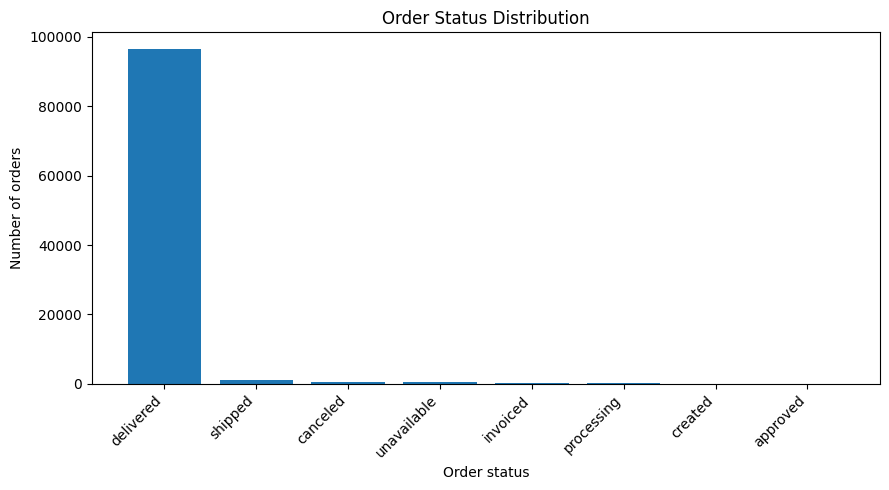

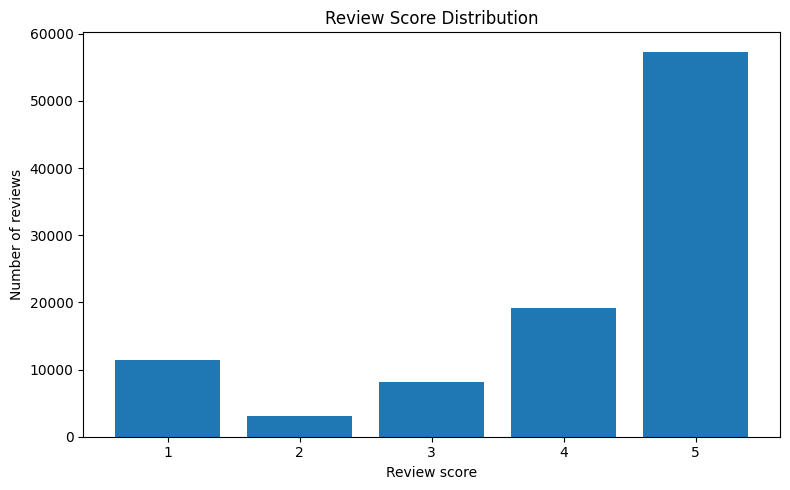

Saved figure: reports/figures/order_status_distribution.png
Saved figure: reports/figures/review_score_distribution.png


In [19]:
plt.figure(figsize=(9, 5))
plt.bar(order_status_distribution["order_status"].astype(str), order_status_distribution["order_count"])
plt.title("Order Status Distribution")
plt.xlabel("Order status")
plt.ylabel("Number of orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
order_status_figure_path = FIGURES_DIR / "order_status_distribution.png"
plt.savefig(order_status_figure_path, dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(review_score_distribution["review_score"].astype(str), review_score_distribution["review_count"])
plt.title("Review Score Distribution")
plt.xlabel("Review score")
plt.ylabel("Number of reviews")
plt.tight_layout()
review_score_figure_path = FIGURES_DIR / "review_score_distribution.png"
plt.savefig(review_score_figure_path, dpi=150)
plt.show()

print(f"Saved figure: {order_status_figure_path.relative_to(PROJECT_ROOT)}")
print(f"Saved figure: {review_score_figure_path.relative_to(PROJECT_ROOT)}")

## 10. Build an order-level analytical table

The original Olist dataset is relational. For exploratory analysis, it is useful to build an order-level table that combines order, customer, item, payment, review, and product-category information.

In [20]:
customers = datasets["customers"].copy()
products = datasets["products"].copy()
category_translation = datasets["category_translation"].copy()

items_with_products = (
    order_items
    .merge(products, on="product_id", how="left")
    .merge(category_translation, on="product_category_name", how="left")
)

items_with_products["product_category_name_english"] = items_with_products["product_category_name_english"].fillna("unknown")

item_summary = (
    items_with_products
    .groupby("order_id", as_index=False)
    .agg(
        item_count=("order_item_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique"),
        total_item_value=("price", "sum"),
        total_freight_value=("freight_value", "sum"),
    )
)

category_revenue_by_order = (
    items_with_products
    .groupby(["order_id", "product_category_name_english"], as_index=False)
    .agg(category_item_value=("price", "sum"))
    .sort_values(["order_id", "category_item_value"], ascending=[True, False])
)

primary_category_by_order = (
    category_revenue_by_order
    .drop_duplicates(subset=["order_id"], keep="first")
    .rename(columns={"product_category_name_english": "primary_product_category"})
    .loc[:, ["order_id", "primary_product_category"]]
)

payment_summary = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        payment_records=("payment_sequential", "count"),
        payment_types=("payment_type", "nunique"),
        max_installments=("payment_installments", "max"),
        total_payment_value=("payment_value", "sum"),
    )
)

main_payment_type = (
    payments
    .groupby(["order_id", "payment_type"], as_index=False)
    .size()
    .sort_values(["order_id", "size", "payment_type"], ascending=[True, False, True])
    .drop_duplicates(subset=["order_id"], keep="first")
    .rename(columns={"payment_type": "main_payment_type"})
    .loc[:, ["order_id", "main_payment_type"]]
)

review_summary = (
    reviews
    .assign(
        has_review_comment=lambda dataframe: (
            dataframe["review_comment_message"].notna()
            | dataframe["review_comment_title"].notna()
        )
    )
    .groupby("order_id", as_index=False)
    .agg(
        review_count=("review_id", "count"),
        average_review_score=("review_score", "mean"),
        has_review_comment=("has_review_comment", "max"),
    )
)

order_level = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(item_summary, on="order_id", how="left")
    .merge(primary_category_by_order, on="order_id", how="left")
    .merge(payment_summary, on="order_id", how="left")
    .merge(main_payment_type, on="order_id", how="left")
    .merge(review_summary, on="order_id", how="left")
)

order_level["order_purchase_month"] = order_level["order_purchase_timestamp"].dt.to_period("M").astype("string")
order_level["days_to_approval"] = (order_level["order_approved_at"] - order_level["order_purchase_timestamp"]).dt.total_seconds() / 86_400
order_level["actual_delivery_days"] = (order_level["order_delivered_customer_date"] - order_level["order_purchase_timestamp"]).dt.total_seconds() / 86_400
order_level["estimated_delivery_days"] = (order_level["order_estimated_delivery_date"] - order_level["order_purchase_timestamp"]).dt.total_seconds() / 86_400
order_level["delivery_delay_days"] = (order_level["order_delivered_customer_date"] - order_level["order_estimated_delivery_date"]).dt.total_seconds() / 86_400
order_level["is_delivered"] = order_level["order_status"].eq("delivered")
order_level["is_late_delivery"] = np.where(
    order_level["order_delivered_customer_date"].notna(),
    order_level["delivery_delay_days"] > 0,
    np.nan,
)
order_level["has_review_comment"] = order_level["has_review_comment"].fillna(False).astype(bool)

order_level.head()

/tmp/ipykernel_29607/3912169470.py:97: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  order_level["has_review_comment"] = order_level["has_review_comment"].fillna(False).astype(bool)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,item_count,unique_products,unique_sellers,total_item_value,total_freight_value,primary_product_category,payment_records,payment_types,max_installments,total_payment_value,main_payment_type,review_count,average_review_score,has_review_comment,order_purchase_month,days_to_approval,actual_delivery_days,estimated_delivery_days,delivery_delay_days,is_delivered,is_late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,1.0,1.0,29.99,8.72,housewares,3.0,2.0,1.0,38.71,voucher,1.0,4.0,True,2017-10,0.007431,8.436574,15.544063,-7.107488,True,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,1.0,1.0,118.70,22.76,perfumery,1.0,1.0,1.0,141.46,boleto,1.0,4.0,True,2018-07,1.279745,13.782037,19.137766,-5.355729,True,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,1.0,1.0,159.90,19.22,auto,1.0,1.0,3.0,179.12,credit_card,1.0,5.0,False,2018-08,0.011505,9.394213,26.639711,-17.245498,True,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,1.0,1.0,45.00,27.20,pet_shop,1.0,1.0,1.0,72.20,credit_card,1.0,5.0,True,2017-11,0.012419,13.208750,26.188819,-12.980069,True,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,1.0,1.0,19.90,8.72,stationery,1.0,1.0,1.0,28.62,credit_card,1.0,5.0,False,2018-02,0.042940,2.873877,12.112049,-9.238171,True,0.0


## 11. Create a customer-level analytical table

This table supports later retention and customer-value analyses.

In [21]:
customer_level = (
    order_level
    .groupby("customer_unique_id", as_index=False)
    .agg(
        customer_state=("customer_state", "first"),
        customer_city=("customer_city", "first"),
        first_purchase_timestamp=("order_purchase_timestamp", "min"),
        last_purchase_timestamp=("order_purchase_timestamp", "max"),
        total_orders=("order_id", "nunique"),
        delivered_orders=("is_delivered", "sum"),
        total_items=("item_count", "sum"),
        total_item_value=("total_item_value", "sum"),
        total_freight_value=("total_freight_value", "sum"),
        total_payment_value=("total_payment_value", "sum"),
        average_review_score=("average_review_score", "mean"),
    )
)

customer_level["average_order_value"] = customer_level["total_payment_value"] / customer_level["total_orders"].replace({0: np.nan})
customer_level["is_repeat_customer"] = customer_level["total_orders"] > 1
customer_level["customer_lifetime_days"] = (customer_level["last_purchase_timestamp"] - customer_level["first_purchase_timestamp"]).dt.days

customer_level.head()

,customer_unique_id,customer_state,customer_city,first_purchase_timestamp,last_purchase_timestamp,total_orders,delivered_orders,total_items,total_item_value,total_freight_value,total_payment_value,average_review_score,average_order_value,is_repeat_customer,customer_lifetime_days
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,cajamar,2018-05-10 10:56:27,2018-05-10 10:56:27,1,1,1.0,129.90,12.00,141.90,5.0,141.90,False,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,osasco,2018-05-07 11:11:27,2018-05-07 11:11:27,1,1,1.0,18.90,8.29,27.19,4.0,27.19,False,0
2,0000f46a3911fa3c0805444483337064,SC,sao jose,2017-03-10 21:05:03,2017-03-10 21:05:03,1,1,1.0,69.00,17.22,86.22,3.0,86.22,False,0
3,0000f6ccb0745a6a4b88665a16c9f078,PA,belem,2017-10-12 20:29:41,2017-10-12 20:29:41,1,1,1.0,25.99,17.63,43.62,4.0,43.62,False,0
4,0004aac84e0df4da2b147fca70cf8255,SP,sorocaba,2017-11-14 19:45:42,2017-11-14 19:45:42,1,1,1.0,180.00,16.89,196.89,5.0,196.89,False,0


## 12. Exploratory analysis

This section creates first-level descriptive summaries. More detailed revenue and retention analysis is performed in notebook 03.

In [22]:
eda_summary_metrics = pd.DataFrame(
    [
        {"metric": "total_orders", "value": int(order_level["order_id"].nunique())},
        {"metric": "total_customers", "value": int(customer_level["customer_unique_id"].nunique())},
        {"metric": "delivered_orders", "value": int(order_level["is_delivered"].sum())},
        {"metric": "total_payment_value", "value": round(order_level["total_payment_value"].sum(), 2)},
        {"metric": "average_order_value", "value": round(order_level["total_payment_value"].mean(), 2)},
        {"metric": "average_review_score", "value": round(order_level["average_review_score"].mean(), 3)},
        {"metric": "repeat_customer_count", "value": int(customer_level["is_repeat_customer"].sum())},
        {"metric": "repeat_customer_rate", "value": round(customer_level["is_repeat_customer"].mean(), 4)},
    ]
)

eda_summary_metrics

,metric,value
0,total_orders,9.944100e+04
1,total_customers,9.609600e+04
2,delivered_orders,9.647800e+04
3,total_payment_value,1.600887e+07
4,average_order_value,1.609900e+02
5,average_review_score,4.087000e+00
6,repeat_customer_count,2.997000e+03
7,repeat_customer_rate,3.120000e-02


### Monthly order volume

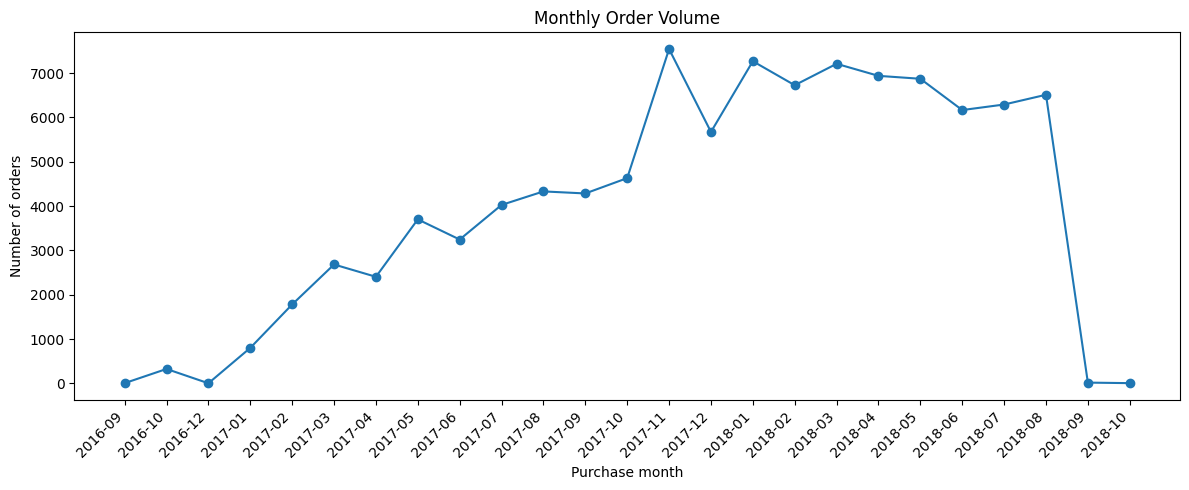

,order_purchase_month,order_count
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


In [23]:
monthly_orders = (
    order_level
    .dropna(subset=["order_purchase_month"])
    .groupby("order_purchase_month", as_index=False)
    .agg(order_count=("order_id", "nunique"))
    .sort_values("order_purchase_month")
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_orders["order_purchase_month"], monthly_orders["order_count"], marker="o")
plt.title("Monthly Order Volume")
plt.xlabel("Purchase month")
plt.ylabel("Number of orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

monthly_orders_figure_path = FIGURES_DIR / "monthly_order_volume.png"
plt.savefig(monthly_orders_figure_path, dpi=150)
plt.show()

monthly_orders.head()

### Top customer states by order count

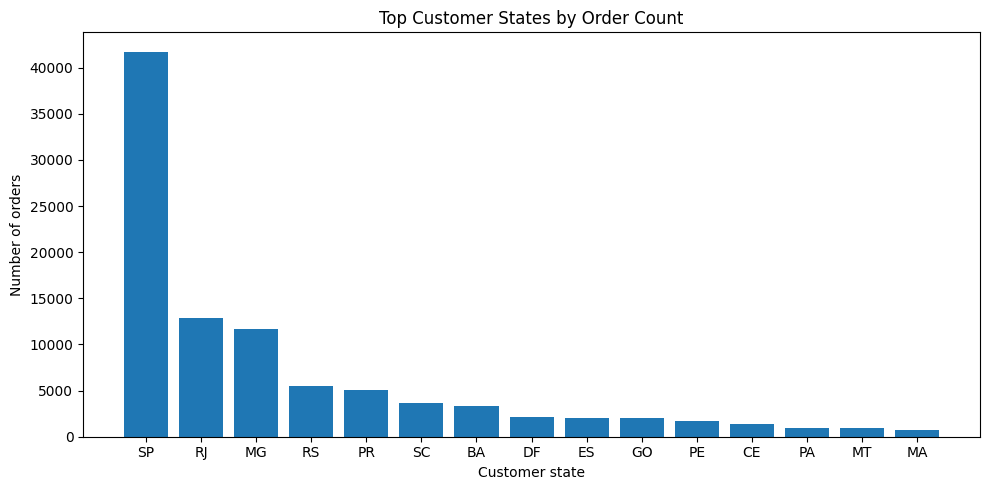

,customer_state,order_count
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


In [24]:
top_customer_states = (
    order_level
    .groupby("customer_state", as_index=False)
    .agg(order_count=("order_id", "nunique"))
    .sort_values("order_count", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 5))
plt.bar(top_customer_states["customer_state"], top_customer_states["order_count"])
plt.title("Top Customer States by Order Count")
plt.xlabel("Customer state")
plt.ylabel("Number of orders")
plt.tight_layout()

top_states_figure_path = FIGURES_DIR / "top_customer_states_by_orders.png"
plt.savefig(top_states_figure_path, dpi=150)
plt.show()

top_customer_states

### Payment type distribution

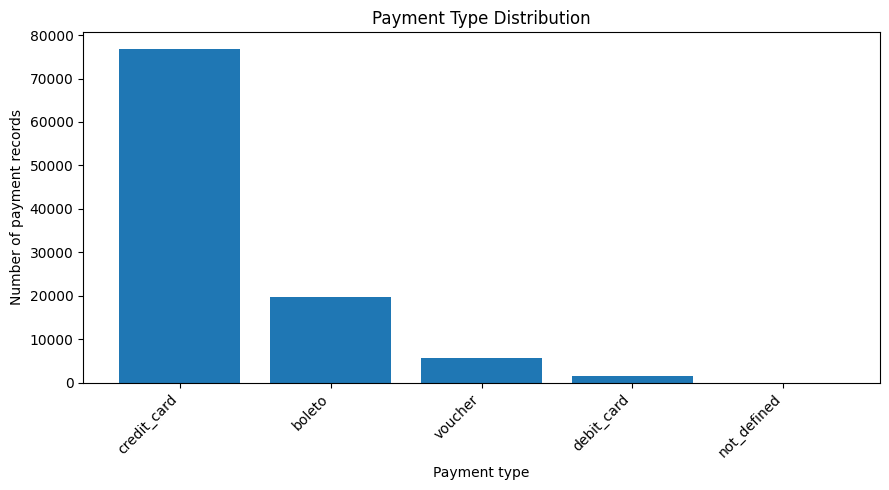

,payment_type,payment_records,payment_value
1,credit_card,76795,12542084.19
0,boleto,19784,2869361.27
4,voucher,5775,379436.87
2,debit_card,1529,217989.79
3,not_defined,3,0.00


In [25]:
payment_type_summary = (
    payments
    .groupby("payment_type", as_index=False)
    .agg(payment_records=("payment_value", "count"), payment_value=("payment_value", "sum"))
    .sort_values("payment_records", ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(payment_type_summary["payment_type"], payment_type_summary["payment_records"])
plt.title("Payment Type Distribution")
plt.xlabel("Payment type")
plt.ylabel("Number of payment records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

payment_type_figure_path = FIGURES_DIR / "payment_type_distribution.png"
plt.savefig(payment_type_figure_path, dpi=150)
plt.show()

payment_type_summary

### Top product categories by item revenue

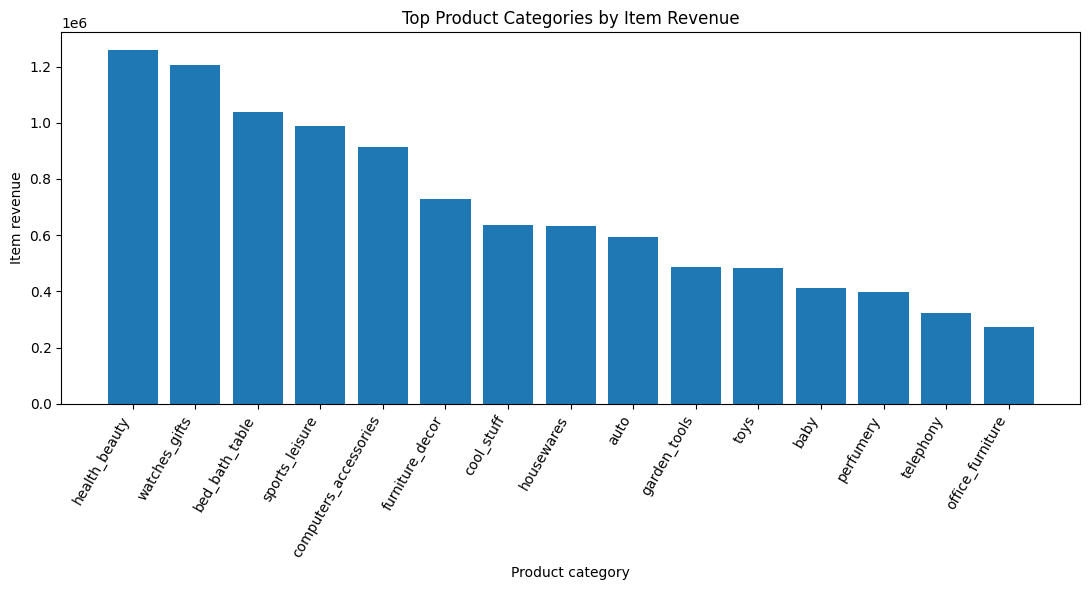

,product_category_name_english,item_revenue,item_count,order_count
43,health_beauty,1258681.34,9670,8836
71,watches_gifts,1205005.68,5991,5624
7,bed_bath_table,1036988.68,11115,9417
65,sports_leisure,988048.97,8641,7720
15,computers_accessories,911954.32,7827,6689
39,furniture_decor,729762.49,8334,6449
20,cool_stuff,635290.85,3796,3632
49,housewares,632248.66,6964,5884
5,auto,592720.11,4235,3897
42,garden_tools,485256.46,4347,3518


In [26]:
top_categories_by_revenue = (
    items_with_products
    .groupby("product_category_name_english", as_index=False)
    .agg(
        item_revenue=("price", "sum"),
        item_count=("order_item_id", "count"),
        order_count=("order_id", "nunique"),
    )
    .sort_values("item_revenue", ascending=False)
    .head(15)
)

plt.figure(figsize=(11, 6))
plt.bar(top_categories_by_revenue["product_category_name_english"], top_categories_by_revenue["item_revenue"])
plt.title("Top Product Categories by Item Revenue")
plt.xlabel("Product category")
plt.ylabel("Item revenue")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()

top_categories_figure_path = FIGURES_DIR / "top_categories_by_item_revenue.png"
plt.savefig(top_categories_figure_path, dpi=150)
plt.show()

top_categories_by_revenue

### Delivery delay distribution

Positive delay means the order arrived after the estimated delivery date. Negative delay means it arrived before the estimated delivery date.

,delivery_delay_days
count,96476.000000
mean,-11.179120
std,10.186113
min,-146.016123
25%,-16.244384
50%,-11.948941
75%,-6.390000
max,188.975081


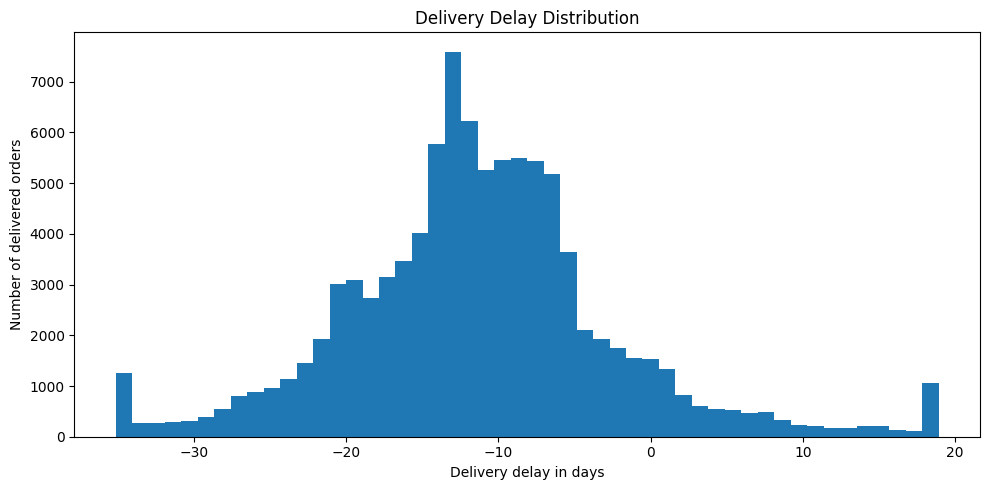

Saved figure: reports/figures/delivery_delay_distribution.png


In [27]:
delivered_orders = order_level.loc[order_level["order_delivered_customer_date"].notna()].copy()

delivery_delay_summary = delivered_orders["delivery_delay_days"].describe()
display(delivery_delay_summary)

delay_lower = delivered_orders["delivery_delay_days"].quantile(0.01)
delay_upper = delivered_orders["delivery_delay_days"].quantile(0.99)
delay_for_plot = delivered_orders["delivery_delay_days"].clip(lower=delay_lower, upper=delay_upper)

plt.figure(figsize=(10, 5))
plt.hist(delay_for_plot.dropna(), bins=50)
plt.title("Delivery Delay Distribution")
plt.xlabel("Delivery delay in days")
plt.ylabel("Number of delivered orders")
plt.tight_layout()

delivery_delay_figure_path = FIGURES_DIR / "delivery_delay_distribution.png"
plt.savefig(delivery_delay_figure_path, dpi=150)
plt.show()

print(f"Saved figure: {delivery_delay_figure_path.relative_to(PROJECT_ROOT)}")

## 13. Create a data-quality issue summary

This table consolidates the main issues found in the validation steps.

In [28]:
quality_issue_records = []

for _, row in duplicate_summary.iterrows():
    quality_issue_records.append(
        {
            "category": "duplicates",
            "check_name": f"exact_duplicates_in_{row['dataset']}",
            "rows_affected": int(row["exact_duplicate_rows"]),
        }
    )

for _, row in key_checks.iterrows():
    quality_issue_records.append(
        {
            "category": "keys",
            "check_name": f"duplicate_key_rows_in_{row['dataset']}",
            "rows_affected": int(row["duplicate_key_rows"]),
        }
    )

for _, row in relationship_checks.iterrows():
    quality_issue_records.append(
        {
            "category": "relationships",
            "check_name": row["relationship"],
            "rows_affected": int(row["orphan_keys"]),
        }
    )

for _, row in date_quality_checks.iterrows():
    quality_issue_records.append(
        {
            "category": "dates",
            "check_name": row["check_name"],
            "rows_affected": int(row["rows_affected"]),
        }
    )

for _, row in numeric_quality_checks.iterrows():
    quality_issue_records.append(
        {
            "category": "numeric_values",
            "check_name": row["check_name"],
            "rows_affected": int(row["rows_affected"]),
        }
    )

quality_issue_summary = (
    pd.DataFrame(quality_issue_records)
    .sort_values(["rows_affected", "category"], ascending=[False, True])
    .reset_index(drop=True)
)

quality_issue_summary

,category,check_name,rows_affected
0,dates,carrier_delivery_before_approval,1359
1,dates,customer_delivery_before_carrier_delivery,23
2,dates,delivered_orders_missing_customer_delivery_date,8
3,dates,non_delivered_orders_with_customer_delivery_date,6
4,numeric_values,non_positive_payment_installments,2
5,dates,approved_before_purchase,0
6,duplicates,exact_duplicates_in_customers,0
7,duplicates,exact_duplicates_in_orders,0
8,duplicates,exact_duplicates_in_order_items,0
9,duplicates,exact_duplicates_in_payments,0


## 14. Export processed datasets and reports

In [29]:
processed_outputs = {
    "data_inventory.csv": data_inventory,
    "missing_values_by_column.csv": missing_by_column,
    "duplicate_summary.csv": duplicate_summary,
    "key_validation.csv": key_checks,
    "relationship_validation.csv": relationship_checks,
    "date_quality_checks.csv": date_quality_checks,
    "numeric_quality_checks.csv": numeric_quality_checks,
    "order_status_distribution.csv": order_status_distribution,
    "payment_type_distribution.csv": payment_type_distribution,
    "review_score_distribution.csv": review_score_distribution,
    "quality_issue_summary.csv": quality_issue_summary,
    "order_level_summary.csv": order_level,
    "customer_level_summary.csv": customer_level,
    "monthly_orders.csv": monthly_orders,
    "top_customer_states.csv": top_customer_states,
    "top_categories_by_revenue.csv": top_categories_by_revenue,
    "eda_summary_metrics.csv": eda_summary_metrics,
}

for file_name, dataframe in processed_outputs.items():
    output_path = PROCESSED_DATA_DIR / file_name
    dataframe.to_csv(output_path, index=False)
    print(f"Created: {output_path.relative_to(PROJECT_ROOT)}")

Created: data/processed/data_inventory.csv
Created: data/processed/missing_values_by_column.csv
Created: data/processed/duplicate_summary.csv
Created: data/processed/key_validation.csv
Created: data/processed/relationship_validation.csv
Created: data/processed/date_quality_checks.csv
Created: data/processed/numeric_quality_checks.csv
Created: data/processed/order_status_distribution.csv
Created: data/processed/payment_type_distribution.csv
Created: data/processed/review_score_distribution.csv
Created: data/processed/quality_issue_summary.csv
Created: data/processed/order_level_summary.csv
Created: data/processed/customer_level_summary.csv
Created: data/processed/monthly_orders.csv
Created: data/processed/top_customer_states.csv
Created: data/processed/top_categories_by_revenue.csv
Created: data/processed/eda_summary_metrics.csv


## 15. Create a Markdown data-quality report

In [30]:
def dataframe_to_markdown_table(dataframe: pd.DataFrame, max_rows: int = 20) -> str:
    """Convert a DataFrame into a simple Markdown table without external dependencies."""
    table = dataframe.head(max_rows).copy()

    if table.empty:
        return "_No records._"

    columns = [str(column) for column in table.columns]
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"

    rows = []
    for _, row in table.iterrows():
        values = [str(row[column]) for column in table.columns]
        rows.append("| " + " | ".join(values) + " |")

    return "\n".join([header, separator, *rows])


report_path = REPORTS_DIR / "data_quality_report.md"

report_content = f"""# Data Quality Report

## Project

Brazilian E-Commerce Analytics Portfolio

## Purpose

This report summarizes the main data-quality checks performed on the raw Olist e-commerce datasets.

## Dataset Inventory

{dataframe_to_markdown_table(data_inventory)}

## Main Quality Issues

{dataframe_to_markdown_table(quality_issue_summary, max_rows=30)}

## Key Validation

{dataframe_to_markdown_table(key_checks)}

## Relationship Validation

{dataframe_to_markdown_table(relationship_checks)}

## Date Validation

{dataframe_to_markdown_table(date_quality_checks)}

## Numeric Validation

{dataframe_to_markdown_table(numeric_quality_checks)}

## EDA Summary Metrics

{dataframe_to_markdown_table(eda_summary_metrics)}

## Generated Figures

- `reports/figures/missing_cells_by_dataset.png`
- `reports/figures/order_status_distribution.png`
- `reports/figures/review_score_distribution.png`
- `reports/figures/monthly_order_volume.png`
- `reports/figures/top_customer_states_by_orders.png`
- `reports/figures/payment_type_distribution.png`
- `reports/figures/top_categories_by_item_revenue.png`
- `reports/figures/delivery_delay_distribution.png`

## Interpretation Notes

- Missing values do not always indicate data errors. For example, undelivered or canceled orders may naturally have missing delivery timestamps.
- Order items and payments are one-to-many tables relative to orders.
- The order-level table aggregates item, payment, review, and customer information for downstream analysis.
- Detailed revenue and retention analysis is performed in the next notebook.
"""

report_path.write_text(report_content, encoding="utf-8")

print(f"Created report: {report_path.relative_to(PROJECT_ROOT)}")

Created report: reports/data_quality_report.md


## Data-quality and EDA summary

This notebook:

- loaded the raw Olist relational datasets;
- summarized missing values, duplicates, and dataset sizes;
- checked primary and composite identifiers;
- validated parent-child relationships;
- evaluated date, numeric, and categorical consistency;
- built order-level and customer-level analytical tables;
- generated exploratory charts;
- exported processed datasets and a Markdown data-quality report.

### Main outputs

```text
data/processed/order_level_summary.csv
data/processed/customer_level_summary.csv
data/processed/quality_issue_summary.csv
reports/data_quality_report.md
reports/figures/
```

### Next notebook

`03_revenue_and_retention_analysis.ipynb` will use the processed analytical tables to answer business questions related to:

- monthly revenue;
- average order value;
- revenue by state and product category;
- repeat purchase behavior;
- customer retention;
- delayed deliveries and review scores.